# Tutorial: Técnicas de Clustering — K-Means y Clustering Jerárquico

En este tutorial exploraremos dos de las técnicas más utilizadas en aprendizaje no supervisado: **K-Means** y **Clustering Jerárquico** (Hierarchical Clustering). Ambos métodos buscan agrupar observaciones en subconjuntos (clusters) de tal forma que las observaciones dentro de un mismo grupo sean lo más similares posible entre sí, y lo más diferentes posible respecto a las de otros grupos.

El tutorial está dividido en tres partes:

1. **Implementación manual de K-Means** sobre un dataset sintético, para comprender la mecánica interna del algoritmo paso a paso.
2. **Aplicación de K-Means con scikit-learn** sobre el dataset real NCI60 (expresión génica de 64 líneas celulares de cáncer), incluyendo reducción de dimensionalidad con PCA e interpretación de resultados.
3. **Clustering Jerárquico** sobre NCI60, comparando diferentes métricas de disimilitud y métodos de enlace (linkage).

---
# Parte 1: Implementación Manual de K-Means sobre Datos Sintéticos

Antes de usar librerías especializadas, es fundamental entender qué hace K-Means internamente. Para ello, trabajaremos con un dataset sintético de 1,000 puntos en dos dimensiones, generado previamente con `make_blobs()` y guardado como CSV. Usaremos K=4 clusters para ilustrar el proceso.

El algoritmo de K-Means opera de la siguiente manera:
1. Se asigna aleatoriamente cada observación a uno de los K clusters.
2. Se calculan los centroides (el vector promedio de cada cluster).
3. Se reasigna cada observación al cluster cuyo centroide esté más cercano (distancia Euclideana).
4. Se repiten los pasos 2 y 3 hasta que las asignaciones dejen de cambiar.

Esta es una búsqueda de **óptimo local**: el objetivo es minimizar la variación intra-cluster (within-cluster variation), es decir, que la dispersión de cada grupo sea lo más baja posible.

## Configuración del entorno e importación de librerías

Comenzamos importando todas las librerías que utilizaremos a lo largo del tutorial:

- **pandas**: Manipulación y análisis de datos tabulares. Nos permite cargar CSVs, crear DataFrames, y realizar operaciones como `groupby` para calcular centroides.
- **matplotlib**: Librería base de visualización en Python. La usaremos para generar gráficas de dispersión, dendrogramas y heatmaps.
- **seaborn**: Construida sobre matplotlib, simplifica la creación de gráficas estadísticas con mejor estética por defecto. Su función `scatterplot` facilita la visualización con colores por categoría.
- **numpy**: Operaciones numéricas eficientes sobre arrays. Esencial para cálculos vectorizados como distancias y selección de mínimos.
- **scipy** (`cdist`, `linkage`, `dendrogram`): Herramientas de cómputo científico. `cdist` calcula matrices de distancia, mientras que `linkage` y `dendrogram` implementan el clustering jerárquico.
- **scikit-learn** (`KMeans`, `PCA`, `StandardScaler`): La librería estándar de machine learning en Python. Provee implementaciones optimizadas de K-Means, reducción de dimensionalidad con PCA, y estandarización de datos.
- **ISLP** (`load_data`): Librería complementaria del libro *Introduction to Statistical Learning with Python*, que nos permite cargar datasets clásicos como NCI60.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data

# Configuración de estética
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

## 1.1 Carga del dataset sintético

Cargamos un dataset con 1,000 observaciones y 2 variables (Feature 1 y Feature 2). Estos datos fueron generados con `sklearn.datasets.make_blobs()` utilizando 3 centros y una desviación estándar de 1.5, lo que produce grupos con cierto grado de solapamiento.

In [2]:
df = pd.read_csv('synthetic_blobs.csv')
print(f"Dimensiones originales: {df.shape}")
df.head()

Dimensiones originales: (1000, 2)


,Feature 1,Feature 2
0,2.056491,6.497202
1,7.979103,-0.178063
2,0.852980,-1.175013
3,7.348619,6.462648
4,5.418338,5.883104


El dataset contiene 1,000 puntos distribuidos en dos dimensiones. Observamos que los valores de ambas variables abarcan un rango amplio, lo cual sugiere la presencia de grupos naturales en los datos. Nótese que en este punto no contamos con etiquetas — estamos simulando un escenario de aprendizaje no supervisado.

## 1.2 Paso 1 del algoritmo: Asignación aleatoria inicial

El primer paso de K-Means consiste en asignar aleatoriamente cada observación a uno de los K clusters. Esto produce una agrupación completamente arbitraria, pero nos da un punto de partida para calcular los primeros centroides.

Utilizamos una semilla (`np.random.seed(123)`) para garantizar la reproducibilidad del experimento. A partir de esta asignación aleatoria, calculamos los centroides iniciales como el promedio de cada variable dentro de cada cluster.

In [3]:
# Semilla para reproducibilidad
np.random.seed(123)
k = 4

# Asignamos etiquetas aleatorias de 0 a k-1
df['Cluster'] = np.random.randint(0, k, size=len(df))

# Calculamos los centroides iniciales (la media de cada variable por cluster)
centroides_iniciales = df.groupby('Cluster')[['Feature 1', 'Feature 2']].mean().reset_index()

print("Centroides de la asignación aleatoria inicial:")
display(centroides_iniciales)

Centroides de la asignación aleatoria inicial:


,Cluster,Feature 1,Feature 2
0,0,3.601265,1.568070
1,1,3.744432,0.933719
2,2,3.945565,1.710432
3,3,3.708145,1.154510


Los centroides iniciales están muy cerca unos de otros (todos alrededor de Feature 1 ≈ 3.5–3.9, Feature 2 ≈ 0.9–1.7). Esto es esperable: al asignar puntos de forma aleatoria, cada cluster contiene una mezcla de observaciones de todas las regiones del espacio, por lo que sus promedios convergen hacia el centro global de los datos. En la siguiente gráfica podemos visualizar esta situación.

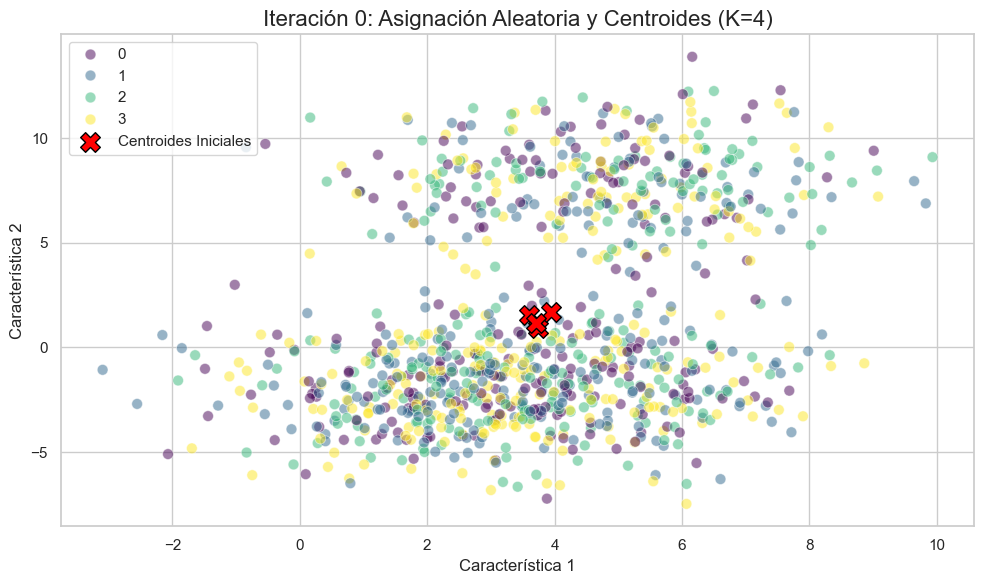

In [4]:
plt.figure(figsize=(10, 6))

# Puntos de datos
sns.scatterplot(data=df, x='Feature 1', y='Feature 2', hue='Cluster', palette='viridis', alpha=0.5, s=60, edgecolor='w')

# Centroides
plt.scatter(centroides_iniciales['Feature 1'], centroides_iniciales['Feature 2'], 
            c='red', marker='X', s=200, label='Centroides Iniciales', edgecolor='black')

plt.title('Iteración 0: Asignación Aleatoria y Centroides (K=4)')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend()
plt.tight_layout()
plt.show()

La gráfica confirma lo esperado: los colores (clusters) están mezclados sin ningún patrón espacial, y los cuatro centroides (marcas rojas) están agrupados en el centro de la nube de datos. A simple vista ya podemos distinguir al menos 3 agrupaciones naturales en los datos, pero el algoritmo aún no las ha descubierto.

## 1.3 Paso 2: Primera iteración — reasignación y recálculo de centroides

Ahora ejecutamos la primera iteración del algoritmo:
1. **Reasignación**: Calculamos la distancia Euclideana de cada observación a los 4 centroides actuales, y la asignamos al cluster del centroide más cercano.
2. **Recálculo**: Con las nuevas asignaciones, recalculamos los centroides.

Usamos `cdist` de scipy para calcular eficientemente la matriz de distancias entre todas las observaciones y todos los centroides. Esta función recibe dos conjuntos de puntos y devuelve una matriz donde cada entrada (i, j) contiene la distancia entre la observación i y el centroide j.

In [5]:
# Extraemos las coordenadas de los datos y los centroides como arrays de numpy
X = df[['Feature 1', 'Feature 2']].values
cent_coords = centroides_iniciales[['Feature 1', 'Feature 2']].values

# 1. Reasignar: Calcular las distancias de cada punto a cada centroide
distancias = cdist(X, cent_coords, metric='euclidean')

# Asignamos el índice del centroide más cercano
df['Cluster_Iter1'] = np.argmin(distancias, axis=1)

# 2. Recalcular los nuevos centroides en base a la nueva columna 'Cluster_Iter1'
centroides_iter1 = df.groupby('Cluster_Iter1')[['Feature 1', 'Feature 2']].mean().reset_index()

print("Nuevos Centroides después de 1 iteración:")
display(centroides_iter1)

Nuevos Centroides después de 1 iteración:


,Cluster_Iter1,Feature 1,Feature 2
0,0,1.359102,4.012241
1,1,3.227963,-2.205631
2,2,5.029607,7.534602
3,3,3.404963,1.113276


Después de una sola iteración, los centroides ya se han separado considerablemente. El Cluster 0 se ubica aproximadamente en (1.4, 4.0), el Cluster 2 en (5.0, 7.5) y el Cluster 1 en (3.2, -2.2), mientras que el Cluster 3 permanece cerca del centro en (3.4, 1.1). Los centroides están comenzando a migrar hacia las regiones densas del dataset, que es exactamente el comportamiento esperado del algoritmo.

## 1.4 Visualización de la primera iteración

Graficamos los datos con las nuevas etiquetas y los nuevos centroides. También incluimos los centroides anteriores (en gris) para observar el desplazamiento.

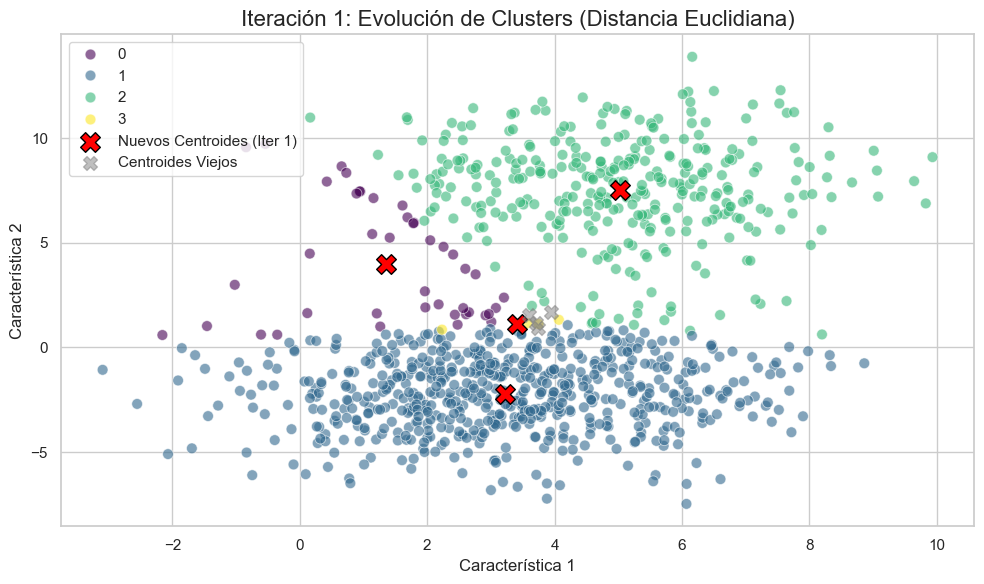

In [6]:
plt.figure(figsize=(10, 6))

# Puntos con nuevas etiquetas
sns.scatterplot(data=df, x='Feature 1', y='Feature 2', hue='Cluster_Iter1', palette='viridis', alpha=0.6, s=60, edgecolor='w')

# Nuevos Centroides
plt.scatter(centroides_iter1['Feature 1'], centroides_iter1['Feature 2'], 
            c='red', marker='X', s=200, label='Nuevos Centroides (Iter 1)', edgecolor='black')

# Añadimos también los centroides viejos para ver el movimiento (opcional, en gris)
plt.scatter(centroides_iniciales['Feature 1'], centroides_iniciales['Feature 2'], 
            c='gray', marker='X', s=100, label='Centroides Viejos', alpha=0.5)

plt.title('Iteración 1: Evolución de Clusters (Distancia Euclidiana)')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend()
plt.tight_layout()
plt.show()

El cambio respecto a la iteración 0 es dramático. Los clusters ya reflejan una estructura espacial coherente: cada color ocupa una región distinta del espacio. Los centroides (marcas rojas) se han movido significativamente desde su posición inicial (marcas grises) hacia los centros naturales de cada grupo.

Si continuáramos iterando, las asignaciones seguirían refinándose hasta estabilizarse. En la práctica, K-Means converge rápidamente (pocas iteraciones) hacia un óptimo local. Sin embargo, es importante destacar que el resultado puede variar según la asignación inicial aleatoria, por lo que es recomendable ejecutar el algoritmo múltiples veces con diferentes inicializaciones y quedarse con la solución que minimice la variación intra-cluster total.

**Nota sobre estocasticidad:** Si eliminamos la semilla y ejecutamos el proceso varias veces, obtendremos resultados distintos. Esto ocurre porque K-Means encuentra óptimos locales, no globales. La práctica estándar es ejecutar el algoritmo con múltiples inicializaciones (el parámetro `n_init` en scikit-learn) y seleccionar la solución con menor inercia.

---
# Parte 2: K-Means sobre el Dataset NCI60 con scikit-learn

Pasamos ahora a un escenario real. El dataset **NCI60** contiene datos de expresión génica (microarrays) para 64 líneas celulares de cáncer. Cada observación es una línea celular descrita por la expresión de 6,830 genes. Además, cada línea tiene una etiqueta que indica su tipo de cáncer (leucemia, melanoma, colon, etc.).

Aunque las etiquetas existen, trabajaremos con K-Means como si no las conociéramos (aprendizaje no supervisado), y después compararemos los clusters generados contra las etiquetas reales para evaluar qué tan bien el algoritmo recupera la estructura biológica subyacente.

## 2.1 Carga y exploración del dataset

Cargamos el dataset NCI60 mediante la función `load_data` de la librería ISLP. Separamos la matriz de expresión génica (`x`) de las etiquetas de tipo de cáncer (`y`) y revisamos la distribución de las clases.

In [7]:
# Importar dataset completo
nci60 = load_data('NCI60')
x = pd.DataFrame(nci60['data'])
y = pd.Series(np.array(nci60['labels']).flatten())

print(f"Dimensiones de X (Genes): {x.shape}")
print(f"Dimensiones de Y (Etiquetas): {y.shape}")

# Crear serie de etiquetas limpia
y_labels = pd.Series(y.values.flatten()) if hasattr(y, 'values') else pd.Series(np.array(y).flatten())

print("\n=== Conteo de Etiquetas (Tipos de Cáncer) ===")
print(f"Total de clases únicas: {len(y_labels.unique())}")
print(y_labels.value_counts())

Dimensiones de X (Genes): (64, 6830)
Dimensiones de Y (Etiquetas): (64,)

=== Conteo de Etiquetas (Tipos de Cáncer) ===
Total de clases únicas: 14
RENAL          9
NSCLC          9
MELANOMA       8
BREAST         7
COLON          7
OVARIAN        6
LEUKEMIA       6
CNS            5
PROSTATE       2
UNKNOWN        1
K562B-repro    1
K562A-repro    1
MCF7A-repro    1
MCF7D-repro    1
Name: count, dtype: int64


El dataset tiene 64 muestras y 6,830 genes. Las etiquetas se distribuyen en 14 tipos de cáncer, aunque la distribución es desbalanceada: RENAL y NSCLC cuentan con 9 muestras cada uno, mientras que algunas categorías (como PROSTATE, UNKNOWN, y las réplicas K562/MCF7) tienen apenas 1 o 2 muestras. Esta distribución desigual es un reto para cualquier algoritmo de clustering.

## 2.2 Visualización exploratoria en el espacio original

Dado que tenemos 6,830 genes, no podemos visualizar todas las dimensiones simultáneamente. Graficamos los dos primeros genes como una exploración inicial, coloreando por tipo de cáncer real.

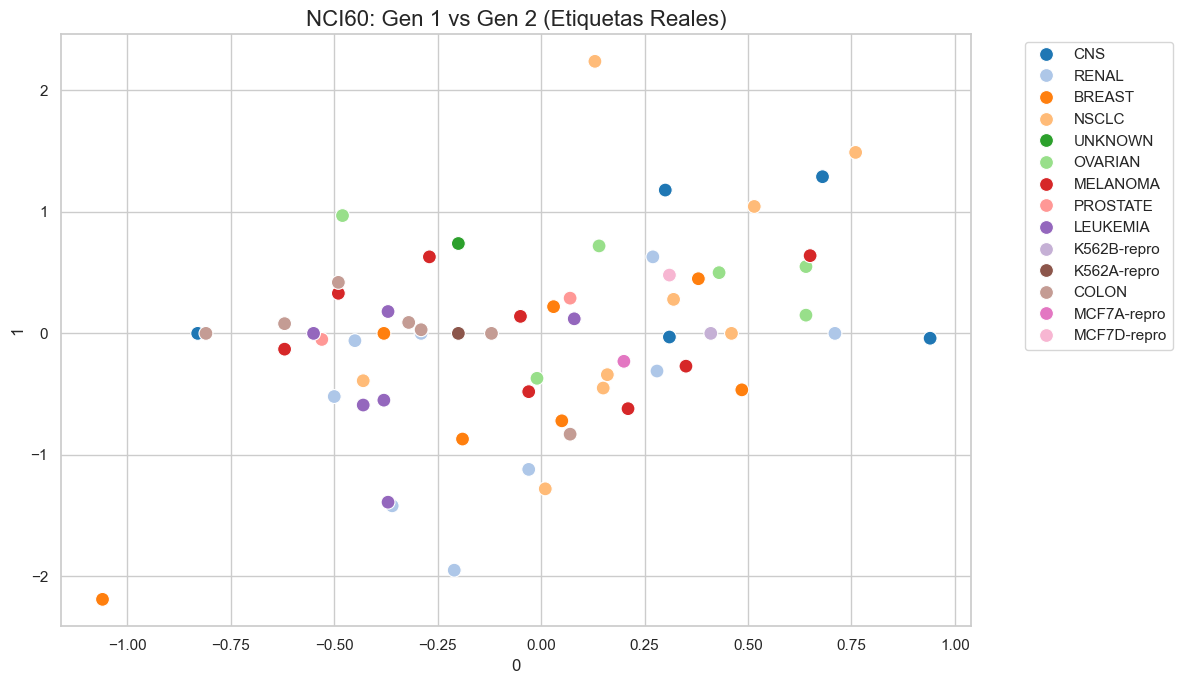

In [8]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x=x.iloc[:, 0], y=x.iloc[:, 1], hue=y_labels, palette='tab20', s=100)
plt.title('NCI60: Gen 1 vs Gen 2 (Etiquetas Reales)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Al graficar solo 2 de 6,830 genes, no se observan clusters bien definidos. Esto no es sorprendente: la información relevante para distinguir tipos de cáncer está distribuida a lo largo de miles de genes, y cualquier proyección a dos dimensiones arbitrarias inevitablemente pierde la mayor parte de la estructura. Necesitamos técnicas de reducción de dimensionalidad para encontrar las direcciones que mejor capturan la varianza del dataset.

## 2.3 Aplicación de K-Means sobre el espacio original

Ejecutamos K-Means directamente sobre las 6,830 dimensiones con K=3, 4 y 5 clusters. Usamos `n_init=10`, lo que significa que el algoritmo se ejecutará 10 veces con diferentes inicializaciones aleatorias y conservará la mejor solución (la que minimice la inercia total).

La clase `KMeans` de scikit-learn encapsula todo el proceso que implementamos manualmente en la Parte 1: inicialización, asignación, recálculo de centroides e iteración hasta convergencia. El método `fit_predict` ejecuta el algoritmo y devuelve directamente las etiquetas de cluster asignadas.

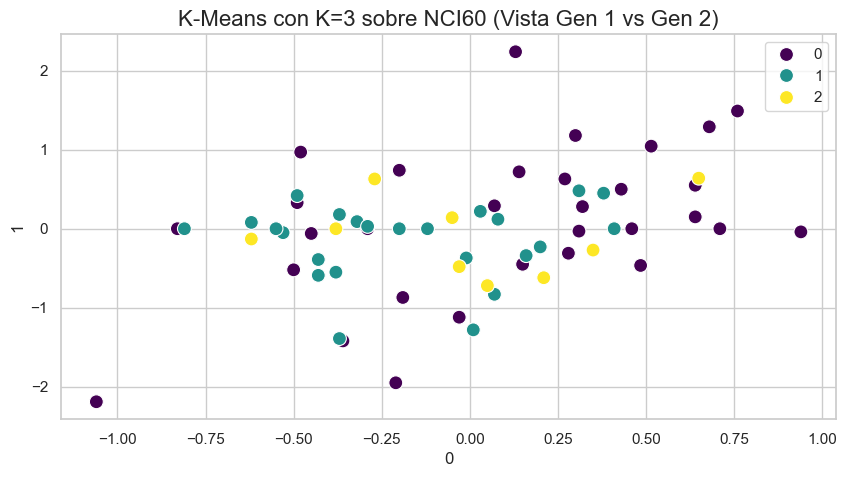

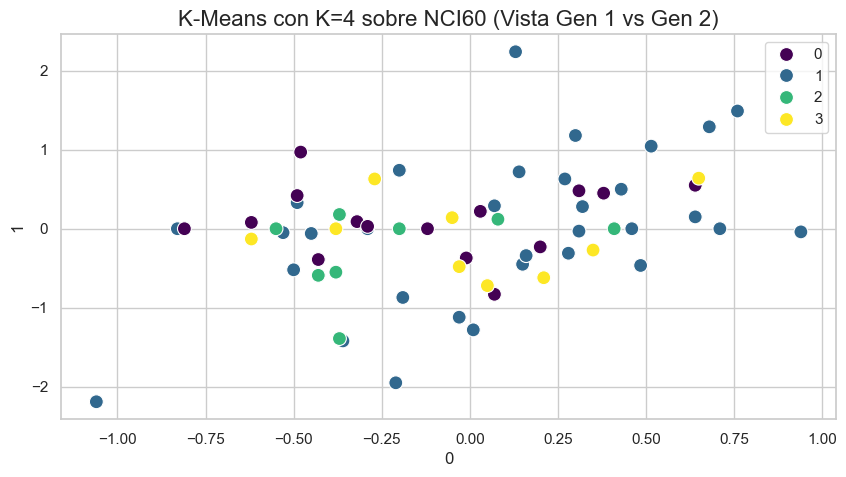

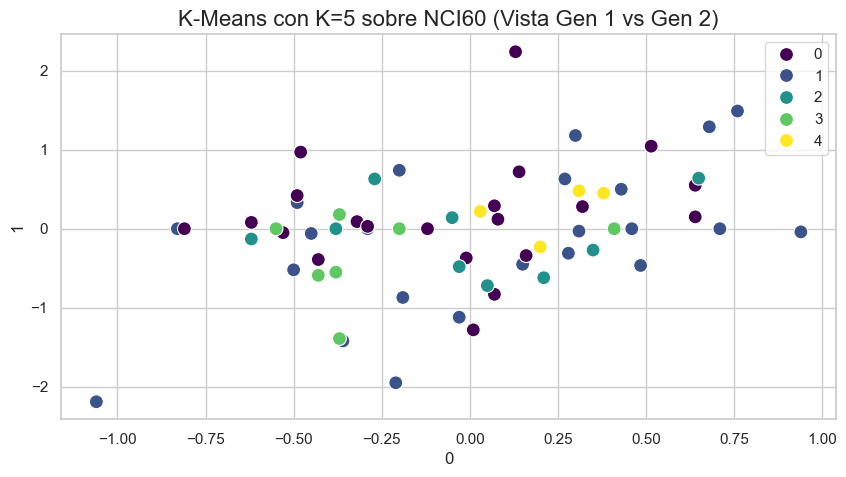

In [9]:
for k_val in range(3, 6):
    kmeans = KMeans(n_clusters=k_val, n_init=10, random_state=42)
    preds = kmeans.fit_predict(x)
    
    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=x.iloc[:, 0], y=x.iloc[:, 1], hue=preds, palette='viridis', s=100)
    plt.title(f'K-Means con K={k_val} sobre NCI60 (Vista Gen 1 vs Gen 2)')
    plt.show()

Las visualizaciones en Gen 1 vs Gen 2 no permiten apreciar la separación de los clusters porque estamos proyectando una estructura de 6,830 dimensiones en solo 2 genes arbitrarios. Los clusters que K-Means encontró existen en el espacio completo de alta dimensionalidad, pero no son visibles en esta proyección. Para poder observar la estructura, necesitamos reducir la dimensionalidad de manera inteligente usando PCA.

## 2.4 Reducción de dimensionalidad con PCA

El Análisis de Componentes Principales (PCA) transforma las variables originales en nuevas variables no correlacionadas, ordenadas por la cantidad de varianza que explican. El primer componente principal (PC1) captura la dirección de máxima varianza, PC2 la segunda mayor, y así sucesivamente.

Antes de aplicar PCA, **estandarizamos los datos** con `StandardScaler`, que transforma cada variable para que tenga media 0 y desviación estándar 1. Esto es crucial porque PCA es sensible a la escala: si un gen tiene valores mucho más grandes que otro, dominaría los componentes principales sin que necesariamente aporte más información biológica.

In [10]:
# Estandarizamos los datos (crucial antes de PCA)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Aplicamos PCA obteniendo los primeros 10 componentes
pca = PCA(n_components=10, random_state=42)
x_pca = pca.fit_transform(x_scaled)

print(f"Dimensiones originales: {x_scaled.shape}")
print(f"Dimensiones después de PCA: {x_pca.shape}")

Dimensiones originales: (64, 6830)
Dimensiones después de PCA: (64, 10)


Pasamos de 6,830 dimensiones a 10 componentes principales. Ahora veamos cuánta información retienen estos componentes.

### Varianza explicada por componente

La gráfica de varianza explicada (scree plot) nos ayuda a decidir cuántos componentes conservar. Buscamos el punto donde agregar más componentes ya no aporta una ganancia sustancial de información (el "codo" de la curva).

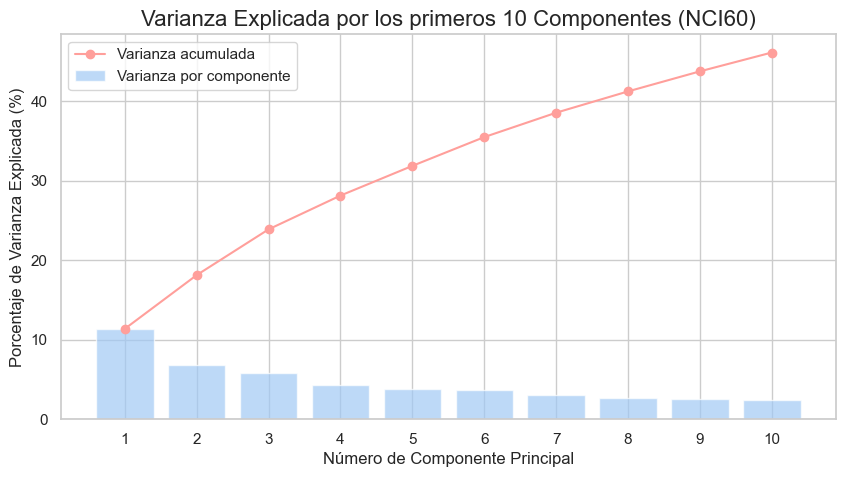

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), pca.explained_variance_ratio_ * 100, alpha=0.7, label='Varianza por componente')
plt.plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_) * 100, marker='o', color='r', label='Varianza acumulada')

plt.xlabel('Número de Componente Principal')
plt.ylabel('Porcentaje de Varianza Explicada (%)')
plt.title('Varianza Explicada por los primeros 10 Componentes (NCI60)')
plt.xticks(range(1, 11))
plt.legend()
plt.show()

El primer componente principal explica aproximadamente el 11% de la varianza total, y la varianza acumulada con 10 componentes ronda el 45-50%. Para datos de microarrays con miles de genes, esto es esperable: la información biológica relevante está dispersa a través de muchos genes. A pesar de que 10 componentes no capturan el 100% de la varianza, capturan la señal más fuerte y filtran buena parte del ruido.

Para la visualización, graficaremos los primeros 3 componentes en combinaciones de pares.

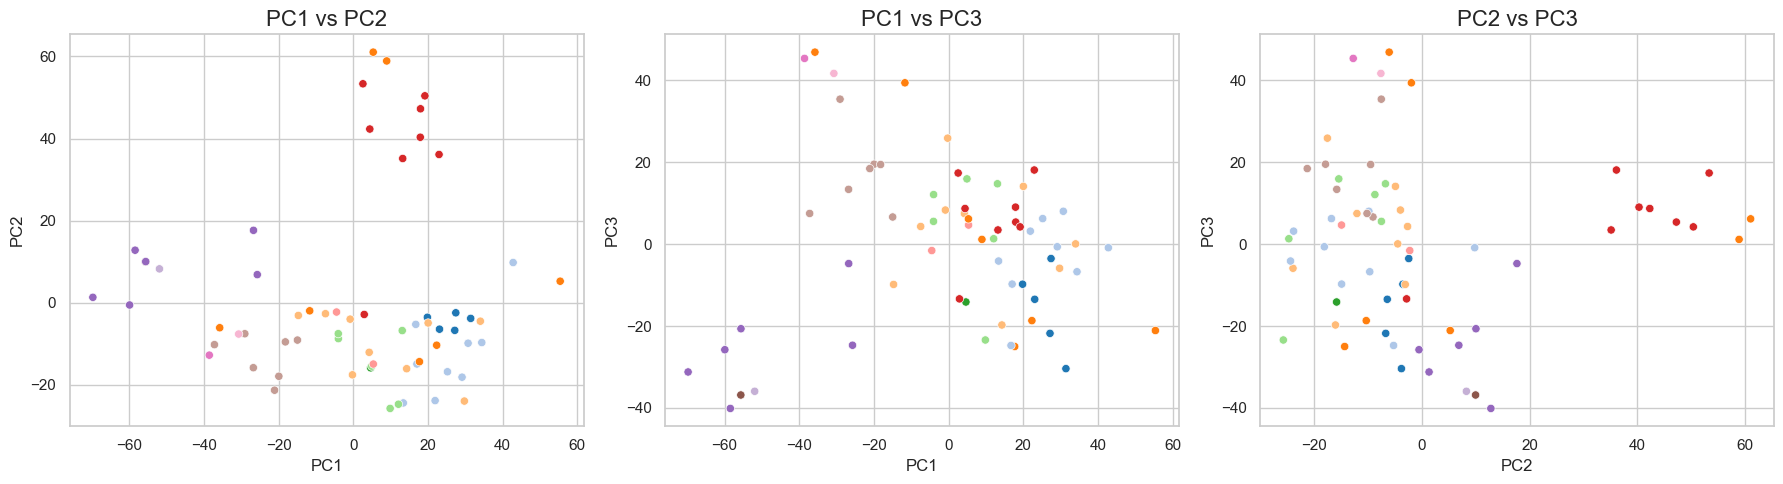

In [12]:
pca_df = pd.DataFrame(x_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
pca_df['Cáncer'] = y_labels.values if hasattr(y_labels, 'values') else y_labels  # Para usar las labels correctas

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PC1 vs PC2
sns.scatterplot(ax=axes[0], data=pca_df, x='PC1', y='PC2', hue='Cáncer', palette='tab20', legend=False)
axes[0].set_title('PC1 vs PC2')

# PC1 vs PC3
sns.scatterplot(ax=axes[1], data=pca_df, x='PC1', y='PC3', hue='Cáncer', palette='tab20', legend=False)
axes[1].set_title('PC1 vs PC3')

# PC2 vs PC3
sns.scatterplot(ax=axes[2], data=pca_df, x='PC2', y='PC3', hue='Cáncer', palette='tab20', legend=False)
axes[2].set_title('PC2 vs PC3')

plt.tight_layout()
plt.show()

Ahora sí podemos apreciar estructura en los datos. En la proyección PC1 vs PC2, algunos tipos de cáncer forman grupos compactos (como la leucemia, que tiende a segregarse claramente), mientras que otros se solapan (como BREAST y OVARIAN). Visualmente, se pueden distinguir entre 3 y 5 grupos principales, lo que justifica explorar K=4 como un valor razonable para K-Means.

Las diferentes combinaciones de componentes principales revelan distintas facetas de la estructura: ciertos tipos de cáncer que se solapan en PC1 vs PC2 pueden separarse en PC1 vs PC3 o PC2 vs PC3.

## 2.5 Interpretación de resultados: Clusters vs. Tipos de Cáncer

Para evaluar la calidad del clustering, comparamos las asignaciones de K-Means (K=4) contra las etiquetas reales mediante una **tabla de contingencia** (generada con `pd.crosstab`). Esta tabla muestra cuántas muestras de cada tipo de cáncer cayeron en cada cluster.

In [13]:
# Ajustamos KMeans con K=4 sobre el dataset NCI60 original
kmeans_nci = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_nci = kmeans_nci.fit_predict(x)

# Crear tabla de clases (y) vs clusters
interpret_df = pd.DataFrame({'Clase': y, 'Cluster': clusters_nci})
tabla_contingencia = pd.crosstab(interpret_df['Clase'], interpret_df['Cluster'])

print("=== Tabla de Clases vs Clusters ===")
display(tabla_contingencia)

=== Tabla de Clases vs Clusters ===


Cluster,0,1,2,3
Clase,,,,
BREAST,2,3,0,2
CNS,0,5,0,0
COLON,7,0,0,0
K562A-repro,0,0,1,0
K562B-repro,0,0,1,0
LEUKEMIA,0,0,6,0
MCF7A-repro,1,0,0,0
MCF7D-repro,1,0,0,0
MELANOMA,0,1,0,7


La tabla revela patrones interesantes:

- **Cluster 0** agrupa principalmente las muestras de COLON (7/7) junto con algunas de OVARIAN y BREAST. Esto sugiere que las líneas celulares de colon tienen un perfil de expresión génica distintivo.
- **Cluster 1** captura la mayoría de NSCLC (8/9), todas las RENAL (9/9) y todas las CNS (5/5). Estos tipos de cáncer comparten patrones de expresión similares según el algoritmo.
- **Cluster 2** agrupa perfectamente a LEUKEMIA (6/6) junto con las réplicas K562. La leucemia tiene un perfil molecular claramente diferenciado del resto.
- **Cluster 3** concentra casi todo el MELANOMA (7/8), otro tipo con firma molecular propia.

Esto demuestra que K-Means, operando sin conocimiento previo de las etiquetas, logra recuperar agrupaciones con coherencia biológica. No es una correspondencia perfecta (algunos tipos se mezclan), pero captura las señales moleculares más fuertes.

### Heatmap de genes diferenciales entre clusters

Para entender *qué genes* distinguen un cluster de otro, seleccionamos los 2 clusters más distintos (Cluster 2 — leucemia y Cluster 3 — melanoma), calculamos la expresión promedio por cluster para cada gen, y visualizamos los 40 genes con mayor diferencia absoluta entre ambos clusters.

Los datos se estandarizan antes de graficar para que el heatmap muestre desviaciones relativas (valores z) en lugar de magnitudes absolutas. La función `sns.heatmap` de seaborn facilita la creación de mapas de calor con escala de colores divergente centrada en cero.

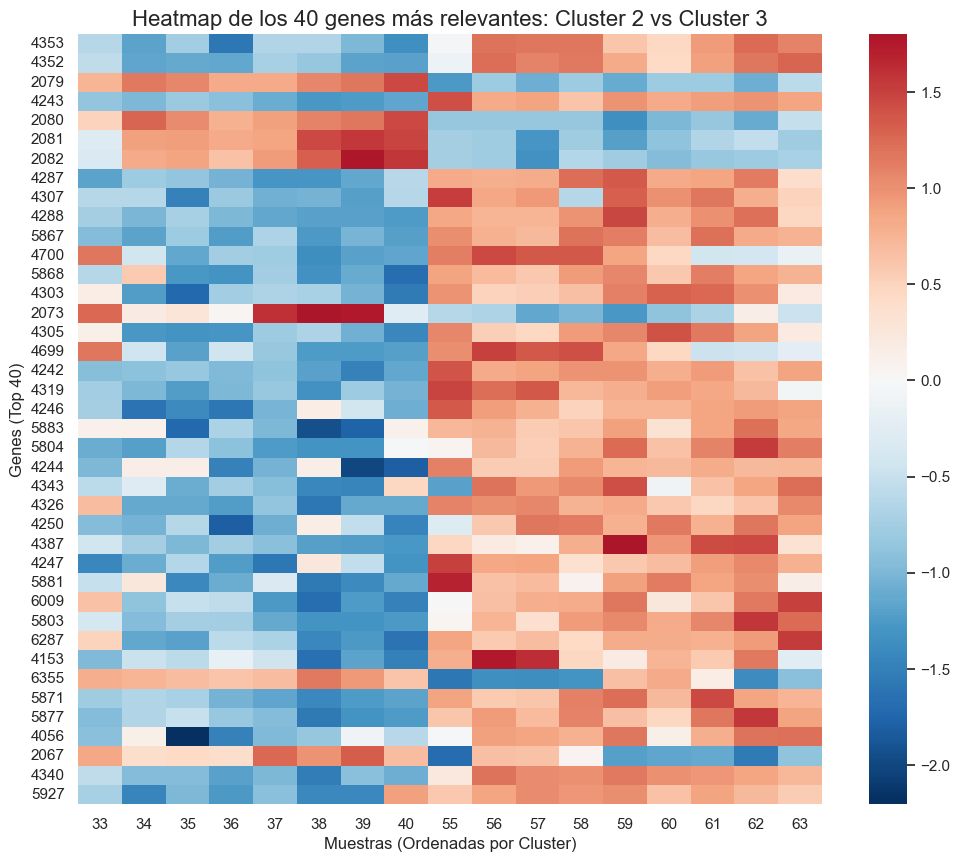

In [14]:
# Seleccionamos el Cluster 2 (Leucemia) y el Cluster 3 (Melanoma)
c_a = 2
c_b = 3
cluster_indices = (clusters_nci == c_a) | (clusters_nci == c_b)
x_subset = x[cluster_indices]
y_subset = clusters_nci[cluster_indices]

# Calcular la expresión promedio por cluster para cada gen
mean_ca = x[clusters_nci == c_a].mean()
mean_cb = x[clusters_nci == c_b].mean()

# Calcular la diferencia absoluta y seleccionar los 40 genes más relevantes
diff_abs = (mean_ca - mean_cb).abs()
top_40_genes = diff_abs.sort_values(ascending=False).head(40).index

# Estandarizar los datos de los 40 genes seleccionados
scaler_heatmap = StandardScaler()
x_top_scaled = pd.DataFrame(
    scaler_heatmap.fit_transform(x_subset[top_40_genes]),
    columns=top_40_genes,
    index=x_subset.index
)

# Agrupar por cluster para la visualización del heatmap
x_top_scaled['Cluster'] = y_subset
x_top_scaled = x_top_scaled.sort_values(by='Cluster')

# Graficar Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(x_top_scaled.drop(columns='Cluster').T, cmap='RdBu_r', center=0)
plt.title(f'Heatmap de los 40 genes más relevantes: Cluster {c_a} vs Cluster {c_b}')
plt.xlabel('Muestras (Ordenadas por Cluster)')
plt.ylabel('Genes (Top 40)')
plt.show()

El heatmap muestra un contraste claro entre ambos clusters. Los colores rojos indican sobreexpresión y los azules subexpresión. Se observa un patrón de bloques nítido: los genes que están sobreexpresados en el cluster de leucemia tienden a estar subexpresados en el de melanoma, y viceversa. Este patrón bicolor confirma que estos dos tipos de cáncer tienen perfiles moleculares marcadamente opuestos en estos genes.

---
# Parte 3: Clustering Jerárquico (Hierarchical Clustering)

El clustering jerárquico ofrece una perspectiva complementaria a K-Means. En lugar de requerir un número K predefinido, construye un **dendrograma** que representa todas las posibles agrupaciones, desde n clusters (cada observación sola) hasta 1 cluster (todas juntas).

El algoritmo aglomerativo funciona así:
1. Se inicia con n observaciones, cada una como su propio cluster.
2. Se calcula la disimilitud entre todos los pares.
3. Se unen los dos clusters más cercanos.
4. Se actualiza la matriz de disimilitudes.
5. Se repiten los pasos 3-4 hasta que quede un solo cluster.

El resultado es un árbol (dendrograma) donde la **altura** de cada unión indica el nivel de disimilitud al que se fusionaron los clusters. Al "cortar" el dendrograma a cierta altura, se obtienen los clusters correspondientes.

Para esta parte usaremos las funciones `linkage` y `dendrogram` de `scipy.cluster.hierarchy`. La función `linkage` recibe la matriz de datos y devuelve una matriz de enlace que codifica la estructura del árbol, mientras que `dendrogram` la visualiza gráficamente.

## 3.1 Preprocesamiento con PCA

Los datos NCI60 ya están cargados de la sección anterior. Para el clustering jerárquico, volvemos a estandarizar y aplicamos PCA calculando todos los componentes posibles (64, dado que tenemos 64 muestras). Esto nos da la flexibilidad de analizar la varianza explicada completa y decidir cuántos componentes conservar.

In [15]:
# Estandarizamos los datos
scaler_hier = StandardScaler()
x_scaled = scaler_hier.fit_transform(x)

# Calculamos PCA para todos los componentes posibles
pca_full = PCA()
x_pca_full = pca_full.fit_transform(x_scaled)

print(f"Transformación completada. Dimensiones originales: {x.shape}")
print(f"Dimensiones en espacio PCA: {x_pca_full.shape}")

Transformación completada. Dimensiones originales: (64, 6830)
Dimensiones en espacio PCA: (64, 64)


### Análisis de varianza explicada (Scree Plot)

Generamos dos vistas: la distribución completa de varianza por componente y un zoom en los primeros 20 componentes con la línea de referencia al 90% de varianza acumulada.

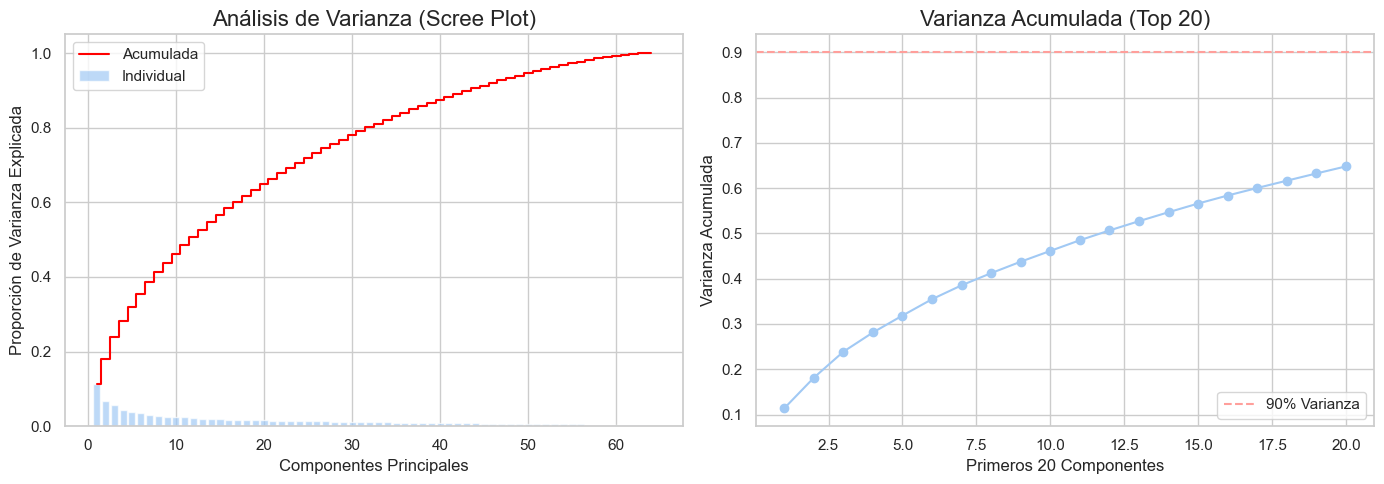

In [16]:
exp_var_ratio = pca_full.explained_variance_ratio_
cum_var_ratio = np.cumsum(exp_var_ratio)

plt.figure(figsize=(14, 5))

# Gráfica individual y acumulada completa
plt.subplot(1, 2, 1)
plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.7, label='Individual')
plt.step(range(1, len(cum_var_ratio) + 1), cum_var_ratio, where='mid', label='Acumulada', color='red')
plt.ylabel('Proporción de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.title('Análisis de Varianza (Scree Plot)')
plt.legend(loc='best')

# Zoom en los primeros componentes para toma de decisión
plt.subplot(1, 2, 2)
plt.plot(range(1, 21), cum_var_ratio[:20], 'bo-')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Varianza')
plt.xlabel('Primeros 20 Componentes')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Acumulada (Top 20)')
plt.legend()

plt.tight_layout()
plt.show()

La gráfica izquierda muestra que la varianza decae progresivamente, sin un "codo" dramático. La gráfica derecha revela que se necesitan aproximadamente 15–17 componentes para alcanzar el 90% de la varianza explicada. Esto confirma que la estructura del NCI60 es inherentemente compleja y multidimensional, lo cual hace que el clustering jerárquico sea particularmente valioso: al no requerir asumir un número fijo de clusters, puede revelar subestructuras a múltiples niveles de resolución.

### Visualización PC1 vs PC2 coloreada por tipo de cáncer

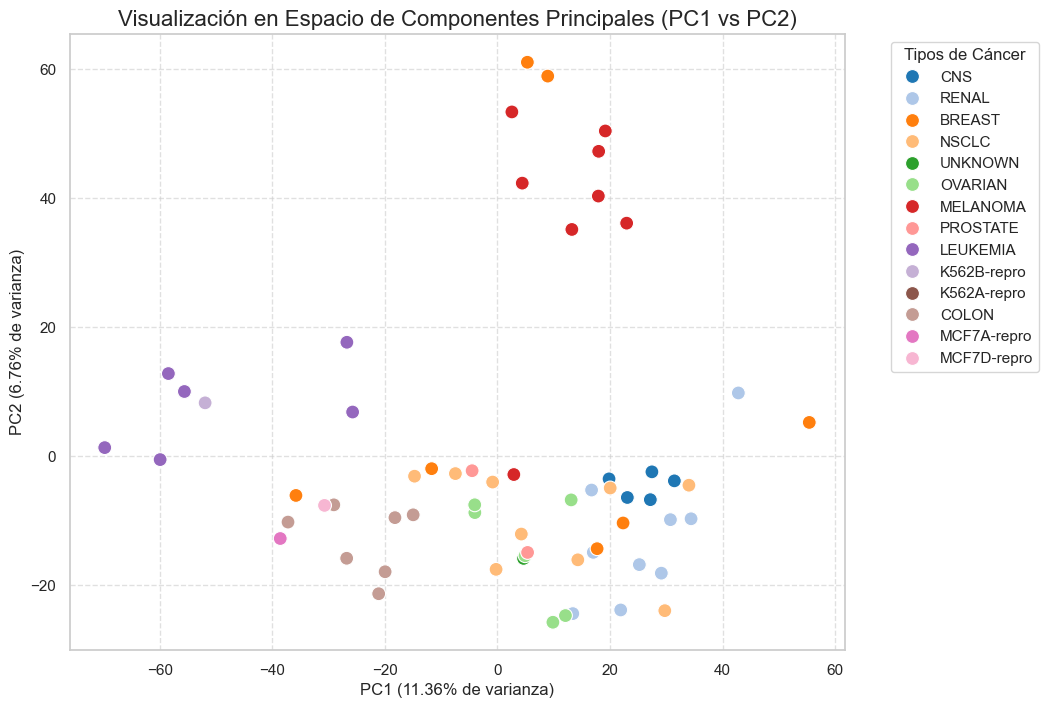

In [17]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=x_pca_full[:, 0], y=x_pca_full[:, 1], hue=y, palette='tab20', s=100)
plt.title('Visualización en Espacio de Componentes Principales (PC1 vs PC2)')
plt.xlabel(f'PC1 ({exp_var_ratio[0]:.2%} de varianza)')
plt.ylabel(f'PC2 ({exp_var_ratio[1]:.2%} de varianza)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Tipos de Cáncer')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Esta proyección muestra que ciertos tipos de cáncer (como LEUKEMIA, en el extremo izquierdo, o MELANOMA) se separan claramente en las primeras dos componentes. Sin embargo, otros tipos (BREAST, OVARIAN, NSCLC, RENAL) muestran solapamiento considerable, lo que sugiere que su diferenciación requiere más dimensiones o métricas distintas a la Euclideana.

## 3.2 Clustering Jerárquico con Enlace Completo y Distancia Euclideana

Comenzamos con la combinación más clásica: **complete linkage** (enlace completo) con **distancia Euclideana**. El enlace completo define la disimilitud entre dos clusters como la máxima distancia entre cualquier par de observaciones (una de cada cluster). Esto tiende a producir clusters compactos y de diámetro similar.

Generamos primero un dendrograma monocromático para observar la estructura completa sin imponer un número de clusters.

In [18]:
# Calculamos la matriz de enlace usando el método 'complete' y métrica Euclideana
Z_complete = linkage(x_scaled, method='complete', metric='euclidean')

print("Matriz de enlace calculada satisfactoriamente.")

Matriz de enlace calculada satisfactoriamente.


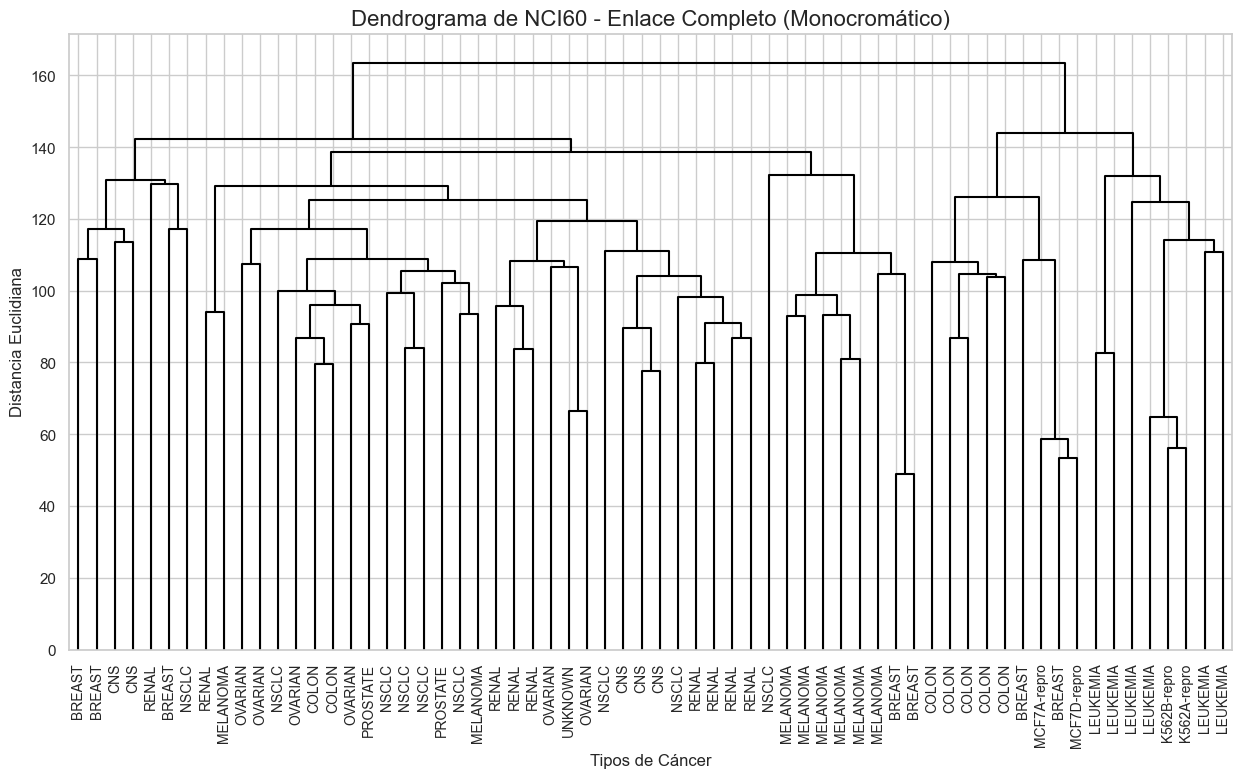

In [19]:
plt.figure(figsize=(15, 8))
plt.title('Dendrograma de NCI60 - Enlace Completo (Monocromático)')
plt.xlabel('Tipos de Cáncer')
plt.ylabel('Distancia Euclidiana')

dendrogram(
    Z_complete,
    labels=y.values,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0,
    above_threshold_color='black',
)

plt.show()

El dendrograma monocromático nos permite leer la estructura jerárquica completa. Cada hoja en la base representa una muestra (etiquetada por tipo de cáncer). Las uniones más bajas conectan las muestras más similares entre sí. Se puede observar que las muestras de LEUKEMIA se agrupan en una rama aislada a una distancia considerablemente mayor que las demás, lo que confirma su perfil molecular distintivo.

La altura máxima del dendrograma indica la disimilitud entre los dos últimos grupos en fusionarse, que representa la mayor diferencia global en el dataset.

## 3.3 Dendrogramas policromáticos: Exploración de diferentes valores de K

Una de las ventajas del clustering jerárquico es que un solo dendrograma codifica todas las posibles particiones. Al "cortar" a distintas alturas (threshold), obtenemos diferentes números de clusters. Visualizamos esto con colores: las ramas por debajo del corte reciben colores distintos, representando clusters separados.

Para calcular el umbral correcto que produzca exactamente K clusters, tomamos el punto medio entre las alturas de las dos últimas fusiones correspondientes.

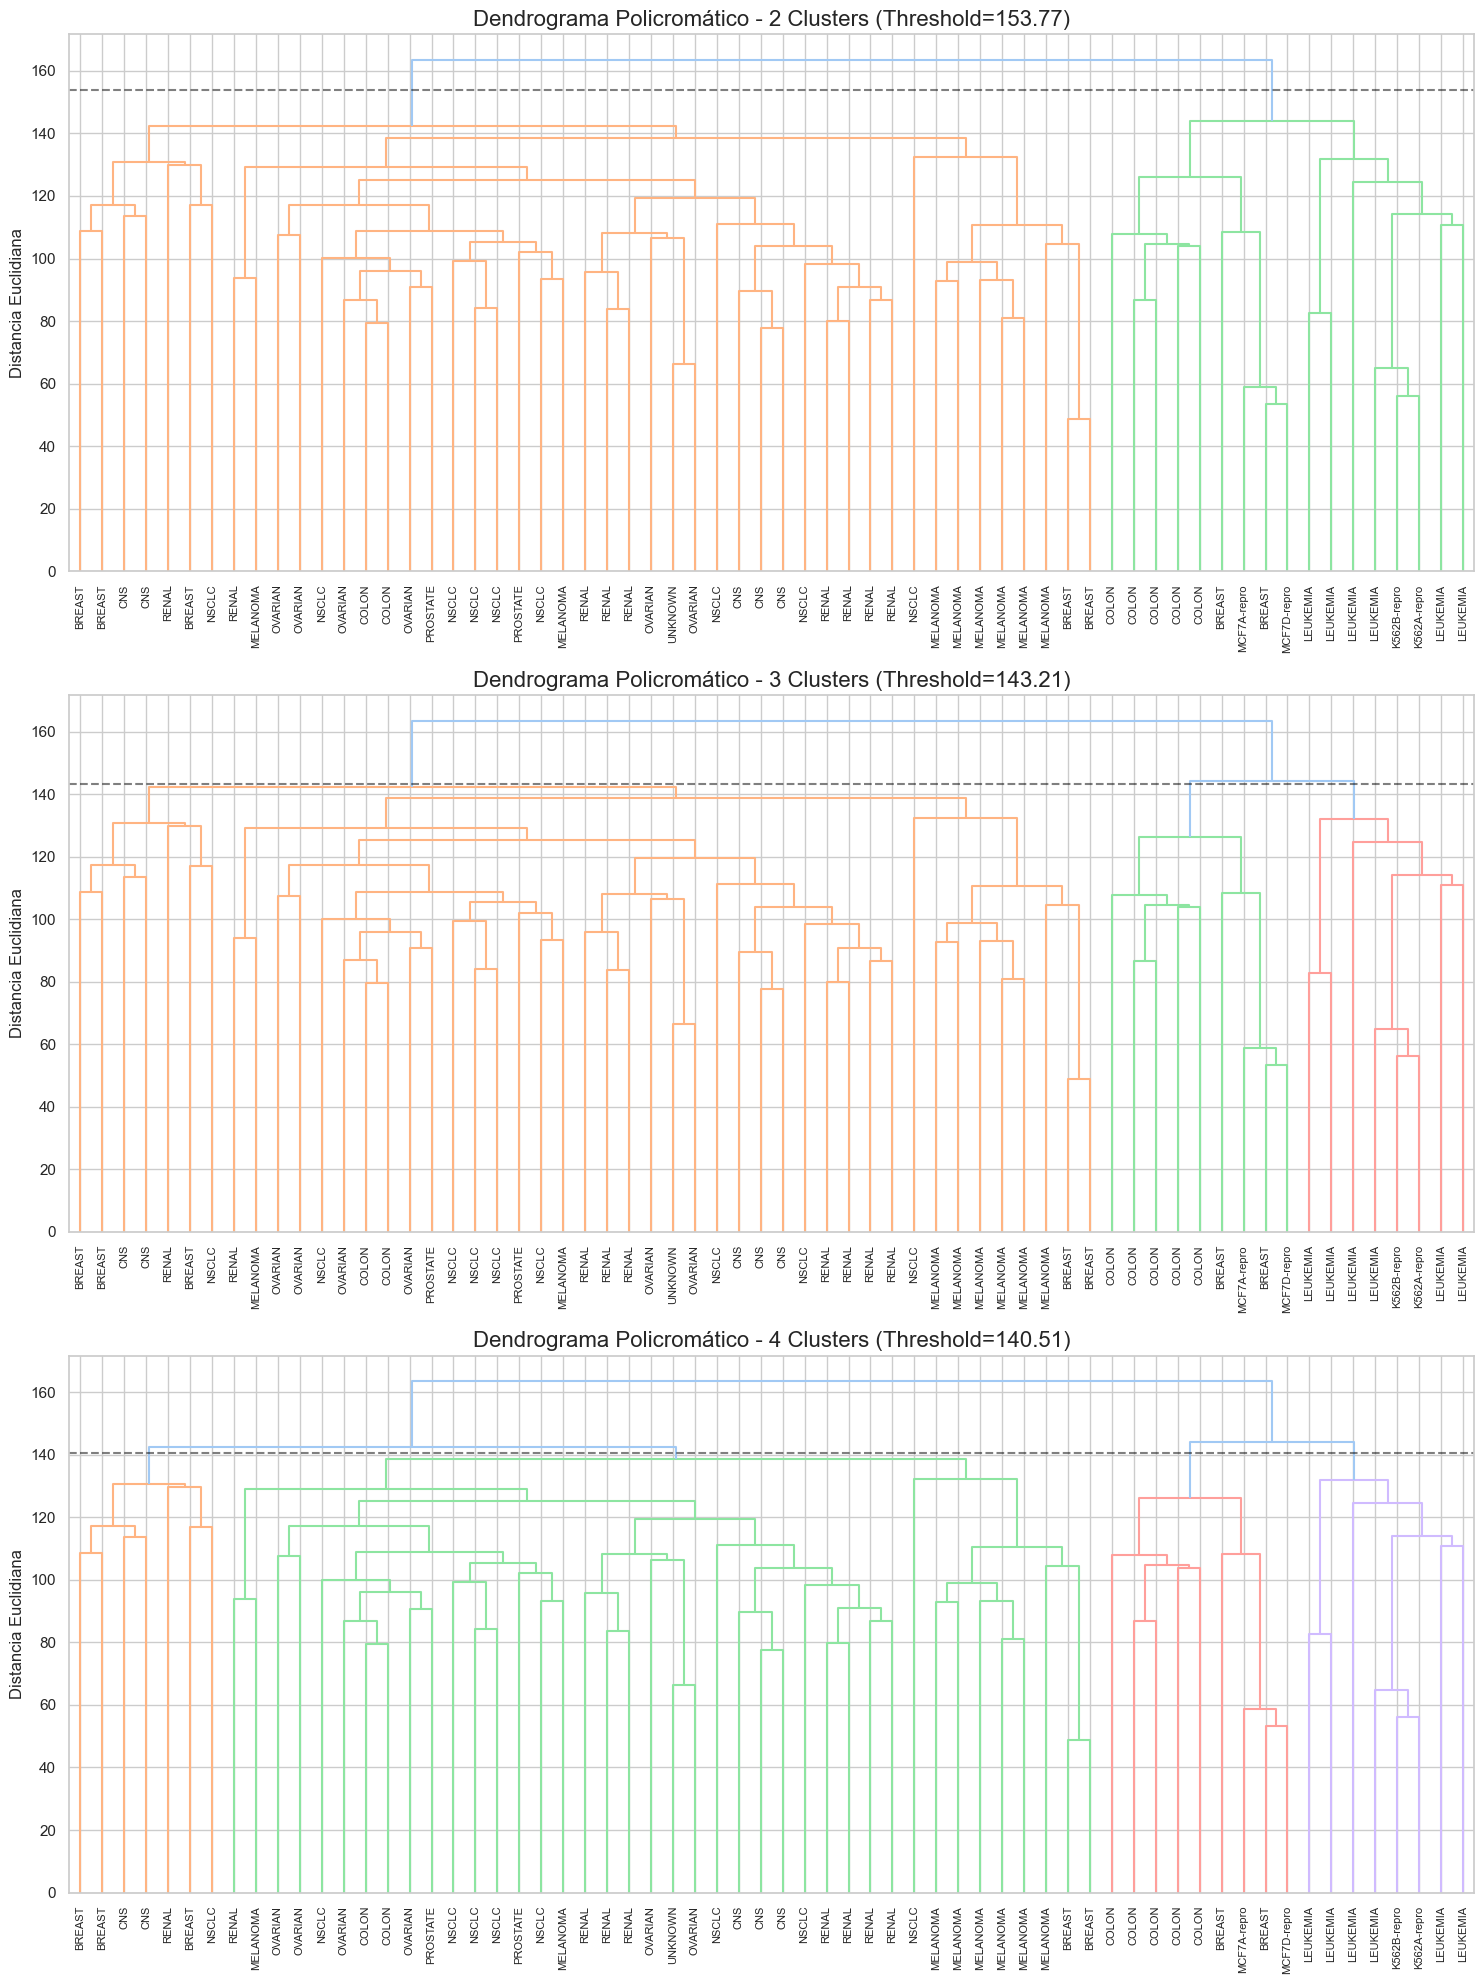

In [20]:
# Obtener las alturas de las uniones de la matriz Z_complete
heights = Z_complete[:, 2]

# Definir umbrales matemáticos para obtener exactamente K clusters
t2 = (heights[-1] + heights[-2]) / 2
t3 = (heights[-2] + heights[-3]) / 2
t4 = (heights[-3] + heights[-4]) / 2

thresholds = {2: t2, 3: t3, 4: t4}

# Graficar comparativa
fig, axes = plt.subplots(3, 1, figsize=(15, 20))

for i, (k, t) in enumerate(thresholds.items()):
    ax = axes[i]
    dendrogram(
        Z_complete,
        labels=y.values,
        leaf_rotation=90,
        leaf_font_size=8,
        color_threshold=t,
        ax=ax
    )
    ax.axhline(y=t, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Dendrograma Policromático - {k} Clusters (Threshold={t:.2f})')
    ax.set_ylabel('Distancia Euclidiana')

plt.tight_layout()
plt.show()

Con **2 clusters**, la división principal separa la leucemia y unas pocas muestras del resto del dataset. Con **3 clusters**, se empieza a distinguir un grupo adicional (típicamente el melanoma). Con **4 clusters**, la resolución aumenta y se identifican subestructuras adicionales.

Es importante notar que en el clustering jerárquico, los clusters están **anidados**: la partición en 3 clusters es un refinamiento de la de 2. Esto puede ser una limitación cuando los grupos naturales no siguen una estructura jerárquica (por ejemplo, si tuviéramos 3 países con 2 profesiones cada uno, la agrupación por profesión no estaría anidada dentro de la agrupación por país).

## 3.4 Comparativa de métricas de disimilitud: Euclideana vs. Correlación

La elección de la métrica de disimilitud tiene un impacto profundo en los resultados del clustering:

- **Distancia Euclideana**: Mide la magnitud de las diferencias. Dos muestras son similares si tienen niveles de expresión parecidos en términos absolutos. Es apropiada cuando interesa el *volumen* (por ejemplo, si una muestra expresa mucho o poco de cada gen).
- **Correlación**: Mide la similitud de *patrones*. Dos muestras son similares si sus genes suben y bajan de forma coordinada, independientemente de la magnitud absoluta. Es apropiada cuando interesa el *perfil* (por ejemplo, si una muestra expresa los mismos genes que otra, aunque a distintos niveles).

Para ilustrar: si una cadena de supermercados quisiera segmentar a sus clientes, la distancia Euclideana agruparía a quienes compran volúmenes similares, mientras que la correlación agruparía a quienes compran los mismos productos independientemente de la cantidad.

In [21]:
# Calculamos la matriz de enlace usando métrica de correlación
Z_correlation = linkage(x_scaled, method='complete', metric='correlation')

print("Cálculo con métrica 'correlation' completado.")

Cálculo con métrica 'correlation' completado.


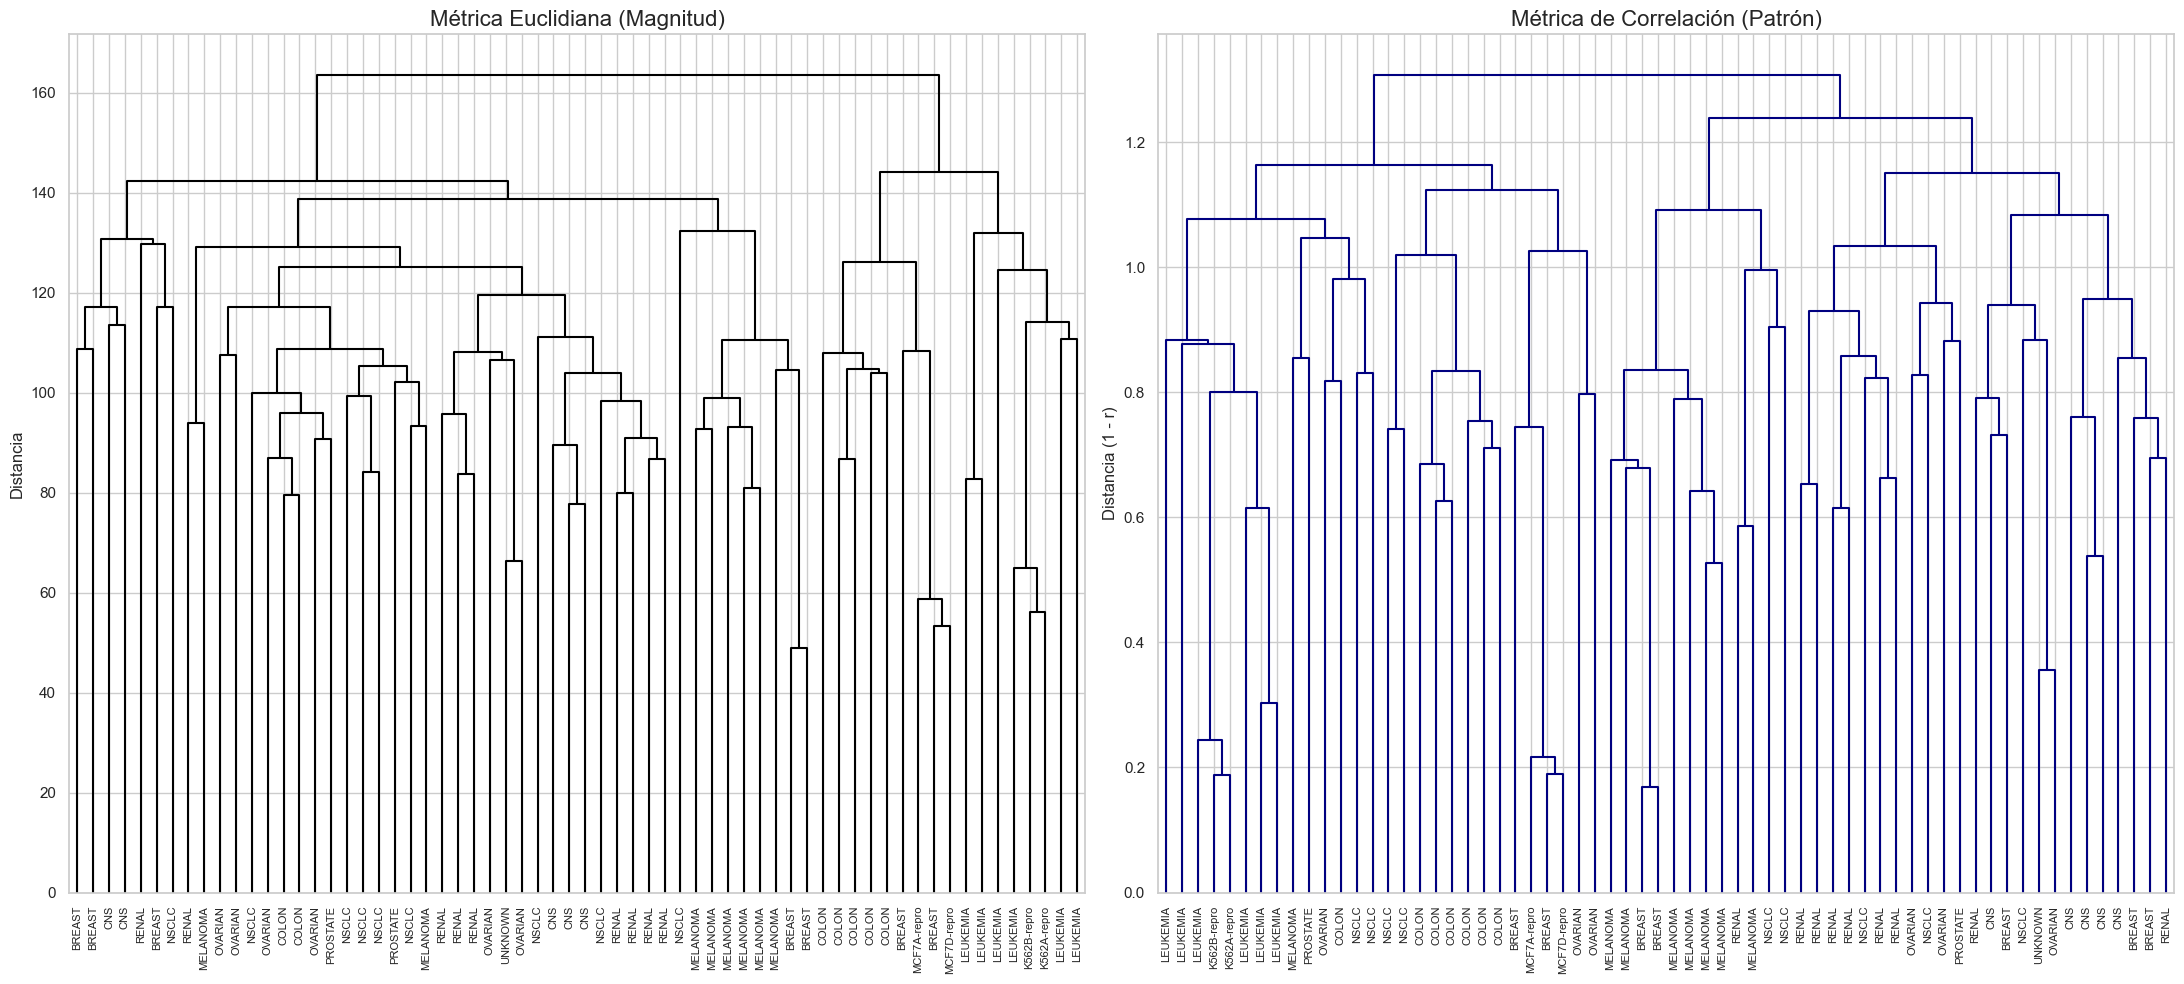

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Dendrograma Euclidiano
dendrogram(
    Z_complete, 
    labels=y.values, 
    leaf_rotation=90, 
    leaf_font_size=8, 
    color_threshold=0, 
    above_threshold_color='black',
    ax=axes[0]
)
axes[0].set_title('Métrica Euclidiana (Magnitud)')
axes[0].set_ylabel('Distancia')

# Dendrograma por Correlación
dendrogram(
    Z_correlation, 
    labels=y.values, 
    leaf_rotation=90, 
    leaf_font_size=8, 
    color_threshold=0, 
    above_threshold_color='navy',
    ax=axes[1]
)
axes[1].set_title('Métrica de Correlación (Patrón)')
axes[1].set_ylabel('Distancia (1 - r)')

plt.tight_layout()
plt.show()

La comparación revela diferencias significativas en la estructura de los clusters:

- Con **distancia Euclideana**, los clusters se forman principalmente por niveles absolutos de expresión. Algunas muestras que comparten el mismo tipo de cáncer pueden separarse si tienen magnitudes de expresión distintas.
- Con **correlación**, los clusters capturan similitud de perfil. Muestras que tienen patrones de expresión paralelos (los mismos genes suben y bajan) se agrupan, incluso si una muestra tiene niveles globales más altos que otra.

Se puede observar cómo ciertos grupos biológicos se vuelven más compactos con una métrica y se fragmentan con la otra. Esto muestra que no existe una métrica "correcta" universalmente: la elección depende de la pregunta biológica que se quiera responder.

## 3.5 Comparativa de métodos de enlace (Linkage)

Cuando el clustering jerárquico necesita comparar dos clusters (no dos observaciones individuales), existen múltiples formas de definir la disimilitud entre ellos:

- **Complete (Completo)**: Usa la máxima distancia entre pares de observaciones. Tiende a producir clusters compactos de diámetro similar, pero puede ser sensible a valores atípicos.
- **Single (Simple)**: Usa la mínima distancia entre pares. Puede producir cadenas largas ("chaining"), pero es bueno detectando clusters con formas irregulares.
- **Average (Promedio)**: Usa el promedio de todas las distancias entre pares. Es un punto medio que suele ser más robusto.
- **Ward**: Minimiza el incremento en la varianza intra-cluster al fusionar. Solo funciona con distancia Euclideana.

Comparamos tres combinaciones: Complete/Euclidean, Complete/Correlation y Average/Euclidean.

In [23]:
# Calculamos la matriz de enlace usando el método 'average'
Z_average = linkage(x_scaled, method='average', metric='euclidean')

print("Cálculo con método 'average' y métrica 'euclidean' completado.")

Cálculo con método 'average' y métrica 'euclidean' completado.


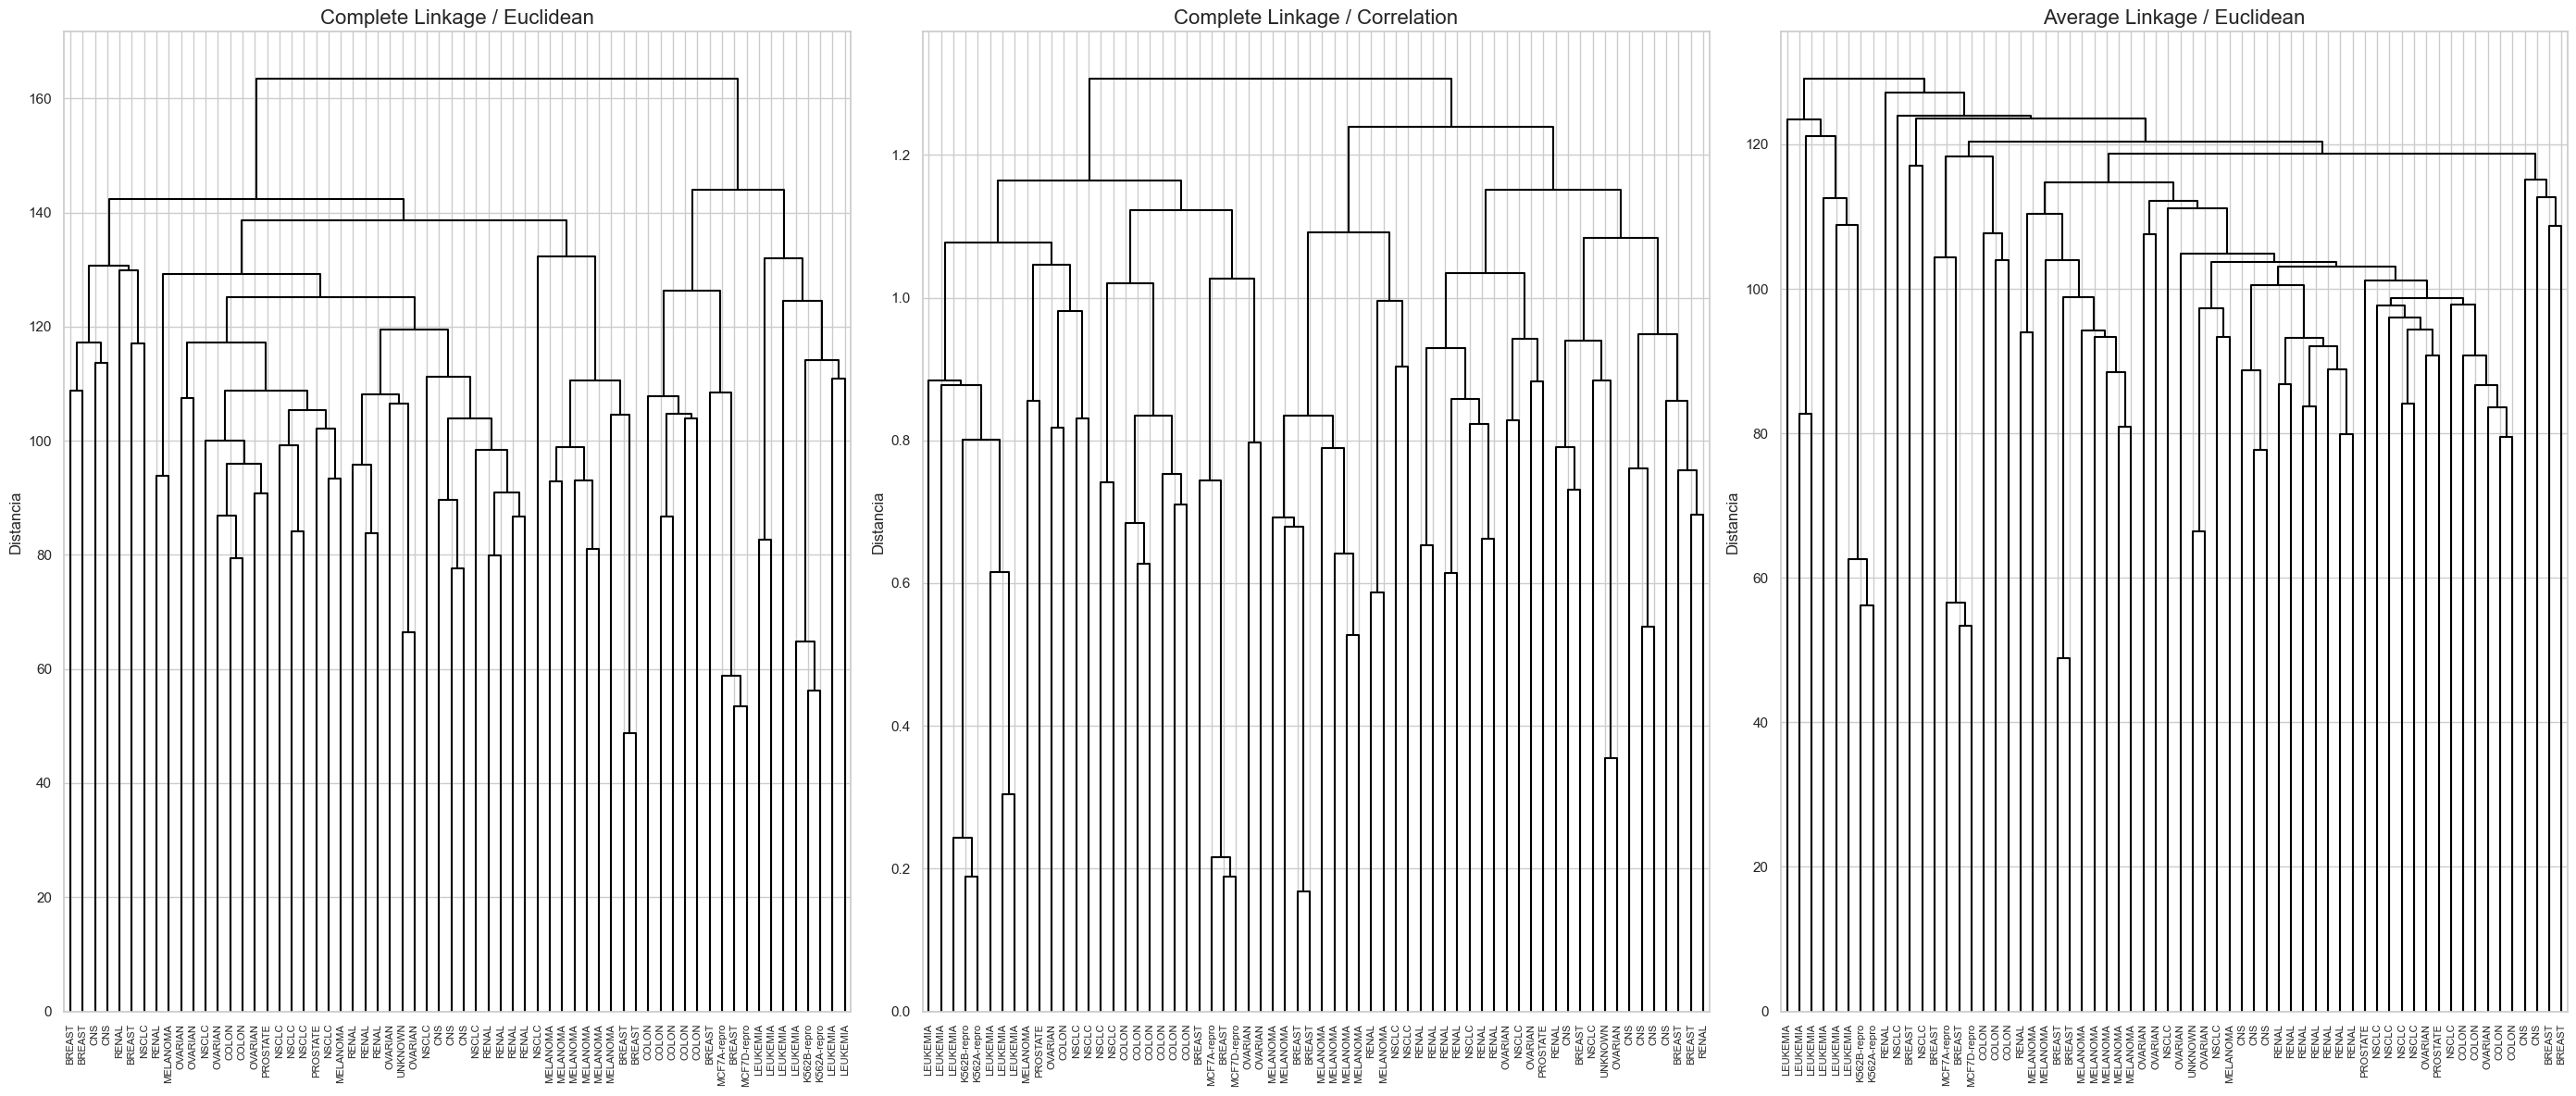

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(28, 12))

# Enlace Completo / Euclidiana
dendrogram(Z_complete, labels=y.values, leaf_rotation=90, leaf_font_size=8, 
           color_threshold=0, above_threshold_color='black', ax=axes[0])
axes[0].set_title('Complete Linkage / Euclidean')
axes[0].set_ylabel('Distancia')

# Enlace Completo / Correlación
dendrogram(Z_correlation, labels=y.values, leaf_rotation=90, leaf_font_size=8, 
           color_threshold=0, above_threshold_color='black', ax=axes[1])
axes[1].set_title('Complete Linkage / Correlation')
axes[1].set_ylabel('Distancia')

# Enlace Promedio / Euclidiana
dendrogram(Z_average, labels=y.values, leaf_rotation=90, leaf_font_size=8, 
           color_threshold=0, above_threshold_color='black', ax=axes[2])
axes[2].set_title('Average Linkage / Euclidean')
axes[2].set_ylabel('Distancia')

plt.tight_layout()
plt.show()

### Análisis comparativo

La comparación de los tres dendrogramas revela:

- **Complete / Euclidean**: Produce clusters relativamente balanceados con fusiones a alturas moderadas. Los tipos de cáncer bien diferenciados (como LEUKEMIA) se aíslan claramente.
- **Complete / Correlation**: Genera una estructura donde la mayoría de las fusiones ocurren a distancias más bajas generalmente, con menos muestras uniéndose a grandes distancias. Esto sugiere que la mayoría de las muestras comparten patrones de expresión similares, y solo unas pocas son verdaderamente distintas en su perfil molecular.
- **Average / Euclidean**: Tiende a producir un dendrograma más "alargado", donde las fusiones ocurren de forma más gradual. Es menos sensible a outliers que el enlace completo, pero puede subestimar la compacidad de ciertos grupos.

Un hallazgo consistente es que, independientemente del método y la métrica, ciertos tipos de cáncer como la leucemia se agrupan de forma aislada y clara. Esto refleja que su firma molecular es robusta y detectable bajo cualquier configuración del algoritmo.

---
# Conclusiones

A lo largo de este tutorial exploramos dos familias de algoritmos de clustering aplicados a datos reales de expresión génica:

**K-Means** es eficiente y produce particiones claras, pero requiere especificar K de antemano y es sensible a la inicialización aleatoria (por lo que es importante usar múltiples inicializaciones con `n_init`). En nuestro análisis, K=4 produjo clusters con buena correspondencia biológica, separando limpiamente leucemia y melanoma del resto.

**Clustering Jerárquico** ofrece mayor flexibilidad al no requerir un K fijo y al producir un dendrograma que puede cortarse a cualquier nivel. Sin embargo, impone una estructura de anidamiento que no siempre refleja la realidad biológica. Su principal ventaja es la riqueza interpretativa: permite explorar múltiples niveles de resolución y comparar el efecto de diferentes métricas y métodos de enlace.

La elección entre distancia Euclideana y correlación depende de la pregunta: si interesa la magnitud de expresión (¿cuánto se expresa?), se usa Euclideana; si interesa el perfil (¿qué genes se co-expresan?), se usa correlación. En ambos casos, la estandarización previa y la reducción de dimensionalidad con PCA son pasos críticos del preprocesamiento.